# **K-Means Clustering Assignment By Rasha**

# KMeans Clustering

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Dog Horse KMeans Challenge

In [107]:
# Import Data
df = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/dog_or_horse.csv")
# We picked variables that we need
X = df[['height', 'weight']]
df.tail(10)

,height,weight,target,type
190,47.0,175.0,1.0,horse
191,64.0,160.0,1.0,horse
192,68.0,157.0,1.0,horse
193,80.0,158.0,1.0,horse
194,80.0,95.0,1.0,horse
195,55.0,140.0,1.0,horse
196,82.0,179.0,1.0,horse
197,46.0,132.0,1.0,horse
198,56.0,89.0,1.0,horse
199,58.0,98.0,1.0,horse


In [108]:
# Scale Data
sc = StandardScaler()
# Fit & transform data.
X_sc=sc.fit_transform(X)
X_sc

array([[-1.11490629, -0.92968047],
       [-1.11490629, -0.38479379],
       [-0.84271237, -1.55240811],
       [-0.95158993, -0.43668776],
       [-1.0604675 , -0.41074077],
       [-0.67939602, -0.48858173],
       [-0.95158993, -0.67021062],
       [-0.89715115, -1.24104429],
       [-1.16934507, -0.79994555],
       [-1.11490629, -1.00752143],
       [-0.78827358, -1.42267319],
       [-0.67939602, -1.00752143],
       [-0.67939602, -1.24104429],
       [-0.95158993, -0.41074077],
       [-1.16934507, -1.73403701],
       [-0.7338348 , -1.34483223],
       [-1.11490629, -0.38479379],
       [-1.0604675 , -0.20316489],
       [-1.11490629, -0.79994555],
       [-1.11490629, -0.3588468 ],
       [-1.11490629, -1.44862017],
       [-0.78827358, -1.31888525],
       [-0.84271237, -0.59236967],
       [-0.7338348 , -0.90373349],
       [-1.00602872, -1.52646113],
       [-0.67939602, -0.74805158],
       [-1.11490629, -0.20316489],
       [-1.11490629, -1.5783551 ],
       [-1.16934507,

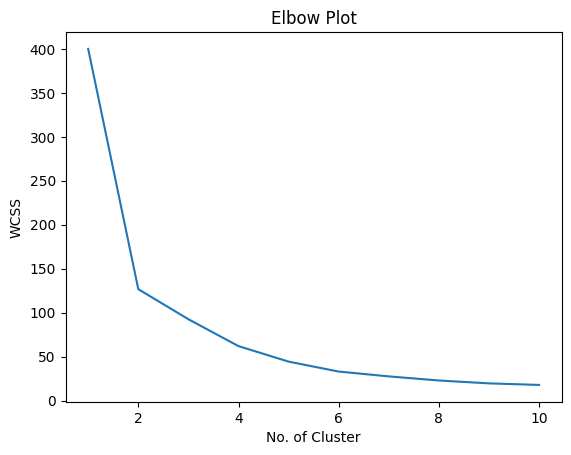

In [109]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for i in range(1,11):
    k=KMeans(n_clusters=i,init='k-means++', random_state=42, n_init=10)
    k.fit(X_sc)
    wcss.append(k.inertia_)

plt.plot(range(1,11),wcss)
plt.title('Elbow Plot')
plt.xlabel('No. of Cluster')
plt.ylabel('WCSS')

plt.show()

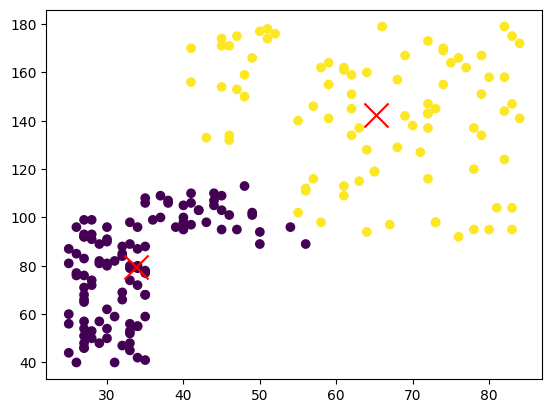

In [110]:
# Apply KMeans and Plot KMeans Results and Actual Results

kf= KMeans(n_clusters=2,init='k-means++',random_state=42, n_init=10)
kf.fit(X_sc)
ykf= kf.predict(X_sc)
plt.scatter(x=df['height'], y=df['weight'], c=ykf)
a= sc.inverse_transform(kf.cluster_centers_)
plt.scatter(x=a[:,0],y=a[:,1],c='red',s=300,marker='x')

In [111]:
print(ykf)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1]


In [112]:
# Cluster centeriods
print (kf.cluster_centers_)

[[-0.74395174 -0.70626086]
 [ 0.96628215  0.91732732]]


In [113]:
# assign the y_kmeans to a new column in the dataset

df['kmean_prid']= ykf
df['target']= df['target'].astype(int)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

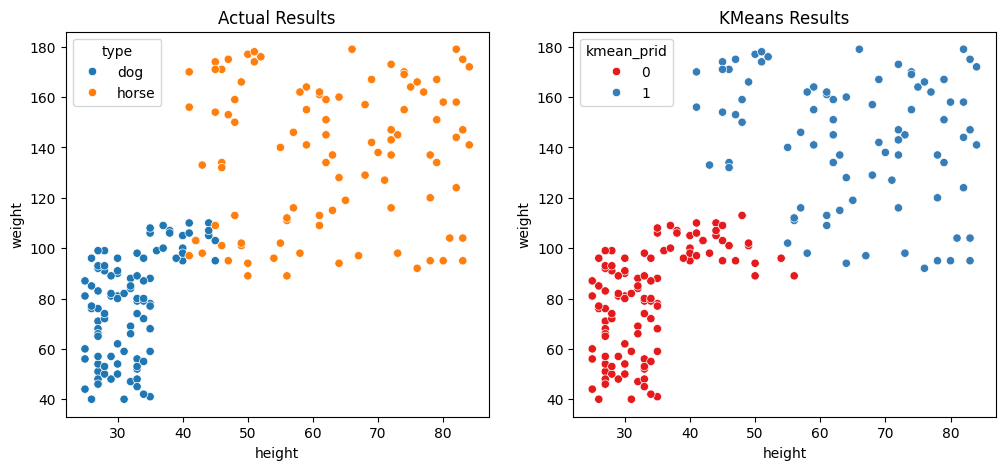

In [114]:
# Create a scatter plot of the actual results and the KMeans results
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(data=df,x='height', y='weight', hue='type', ax=ax[0])

ax[0].set_title("Actual Results")

sns.scatterplot(data=df,x='height',y='weight',hue='kmean_prid',palette='Set1',ax=ax[1])

ax[1].set_title("KMeans Results")

plt.show()

In [115]:
# replace dog with 1 and horse with 0 to help us caluclate the Accuracy Score
df['type'] = df['type'].map({'dog':0,'horse':1})

df.head()

,height,weight,target,type,kmean_prid
0,27.0,71.0,0,0,0
1,27.0,92.0,0,0,0
2,32.0,47.0,0,0,0
3,30.0,90.0,0,0,0
4,28.0,91.0,0,0,0


In [116]:
# Calculate the number of correct predictions
(df['type'] == df['kmean_prid']).value_counts()

True     187
False     13
Name: count, dtype: int64

In [117]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df['type'], df['kmean_prid'])*100

93.5

# Seattle Weather KMeans Challenge

In [146]:
df_sea = pd.read_csv("https://raw.githubusercontent.com/gumdropsteve/datasets/master/seattle_weather_1948-2017.csv")
X_sea = df_sea[['tmax', 'tmin']]
df_sea.head()

,ds,prcp,tmax,tmin,rain
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [147]:
# Scale Data
sc_sea = StandardScaler()
# Fit & transform data.
X_sea_sc = sc_sea.fit_transform(X_sea)

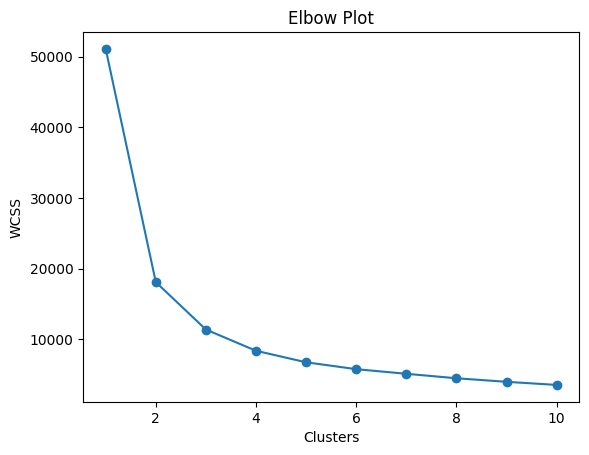

In [148]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sea_sc)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Plot")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


# From the plot we can see that the optimal number of clusters in 4, but our target is 2 so we should pick 2.

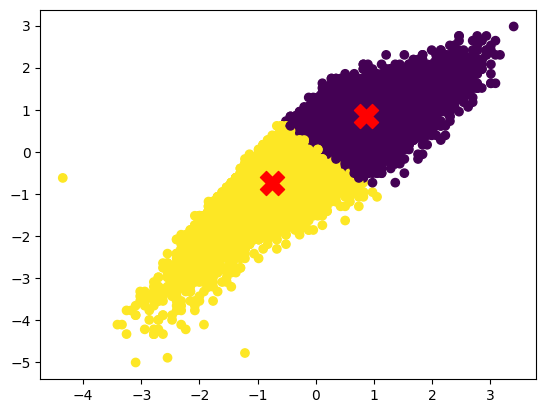

In [149]:

# Apply KMeans and Plot KMeans Results and Actual Results
kmeans_sea = KMeans(
    n_clusters=2,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_sea_kmeans = kmeans_sea.fit_predict(X_sea_sc)

plt.scatter(
    X_sea_sc[:,0],
    X_sea_sc[:,1],
    c=y_sea_kmeans,
    cmap='viridis'
)

plt.scatter(
    kmeans_sea.cluster_centers_[:,0],
    kmeans_sea.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.show()

In [150]:
print(y_sea_kmeans)

[1 1 1 ... 1 1 1]


In [151]:
# assign the y_kmeans to a new column
df_sea['kmean_sea_prid']= y_sea_kmeans
df_sea

,ds,prcp,tmax,tmin,rain,kmean_sea_prid
0,1948-01-01,0.47,51,42,True,1
1,1948-01-02,0.59,45,36,True,1
2,1948-01-03,0.42,45,35,True,1
3,1948-01-04,0.31,45,34,True,1
4,1948-01-05,0.17,45,32,True,1
...,...,...,...,...,...,...
25546,2017-12-10,0.00,49,34,False,1
25547,2017-12-11,0.00,49,29,False,1
25548,2017-12-12,0.00,46,32,False,1
25549,2017-12-13,0.00,48,34,False,1


In [152]:
# replace True with 1 and False with 0 to help us caluclate the Accuracy Score
df_sea['rain'] = df_sea['rain'].map({True:1, False:0})

In [153]:
# Calculate the number of correct predictions
(df_sea['rain'] == df_sea['kmean_sea_prid']).value_counts()

True     16266
False     9285
Name: count, dtype: int64

In [154]:
df_sea.dropna(subset = ['rain'], inplace=True)

In [155]:
df_sea['rain'].isna().sum()

np.int64(0)

### Plot the clusters including the centroid for each of the clusters as defined by K-Means

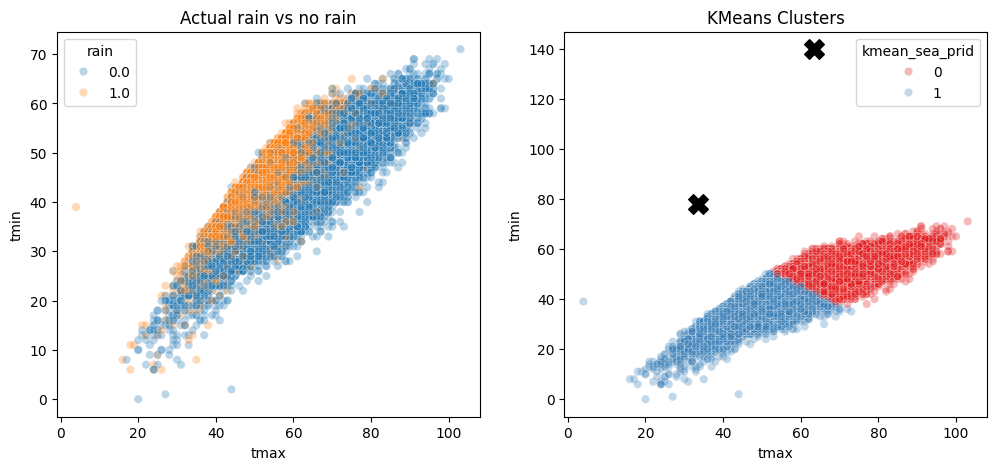

In [157]:
# Plot the clusters including the centroid for each of the clusters as defined by K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df_sea, x='tmax', y='tmin', hue='rain', ax=axes[0], alpha=0.3)
axes[0].set_title('Actual rain vs no rain')

sns.scatterplot(data=df_sea, x='tmax', y='tmin', hue='kmean_sea_prid', palette='Set1', ax=axes[1], alpha=0.3)
centers_orig = sc.inverse_transform(kmeans_sea.cluster_centers_)
axes[1].scatter(centers_orig[:,0], centers_orig[:,1], s=200, c='black', marker='X')
axes[1].set_title('KMeans Clusters')
plt.show()

In [158]:
# Compute Accuracy Score of KMean Labels with True Labels
accuracy_score(df_sea['rain'], df_sea['kmean_sea_prid'])*100

63.66838891498357

# Random Blob KMeans Challenge

- You dont have true labels for this data so this is truly an unsupervised dataset
- The blobs are randomly generated every time you run the cell and their characteristics are:
    - 2000-4000 data points
    - 10-30 blobs created

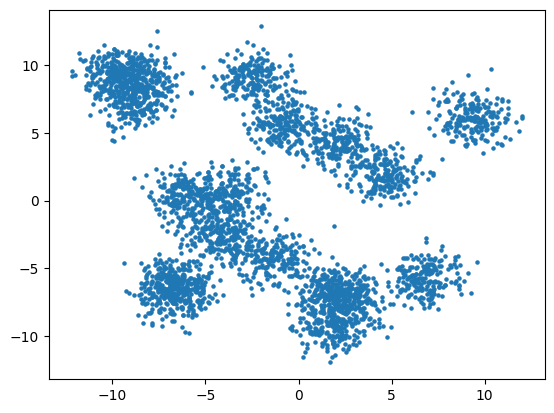

In [176]:
n_samples=np.random.randint(2000,4001)
n_blobs=np.random.randint(10,31)
X_blob, y_blb = make_blobs(n_samples=n_samples, centers=n_blobs, random_state=42)
df_blob = pd.DataFrame(X_blob, columns=['x1', 'x2'])
plt.scatter(df_blob['x1'],df_blob['x2'], s=5)

In [177]:
# Scale Data
sc_blb = StandardScaler()
# Fit & transform data.
X_blb_sc = sc.fit_transform(df_blob)

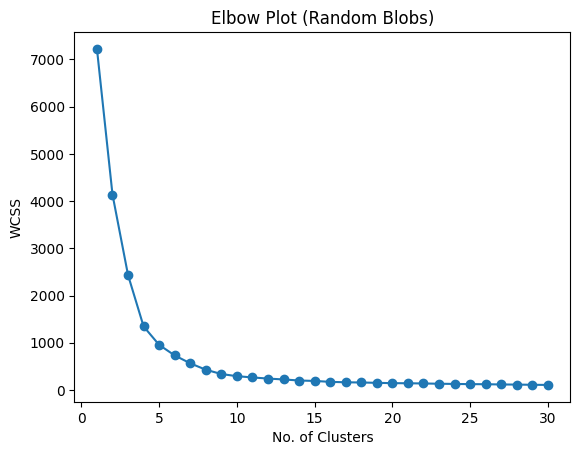

In [178]:
# Create Elbow Plot

# The elbow method depends on WCSS which stands for Within Cluster Sum of Squares

wcss = []
# Note: We are using K-mean++ to avoid the random initialization trap 
# Note: We are creating a plot of the WCSS for upto 10 clusters using the for loop
# The measurement we are using is the inertia 
for i in range(1, 31):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_blb_sc)
    wcss.append(km.inertia_)

plt.plot(range(1,31), wcss, marker='o')
plt.title('Elbow Plot (Random Blobs)')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()


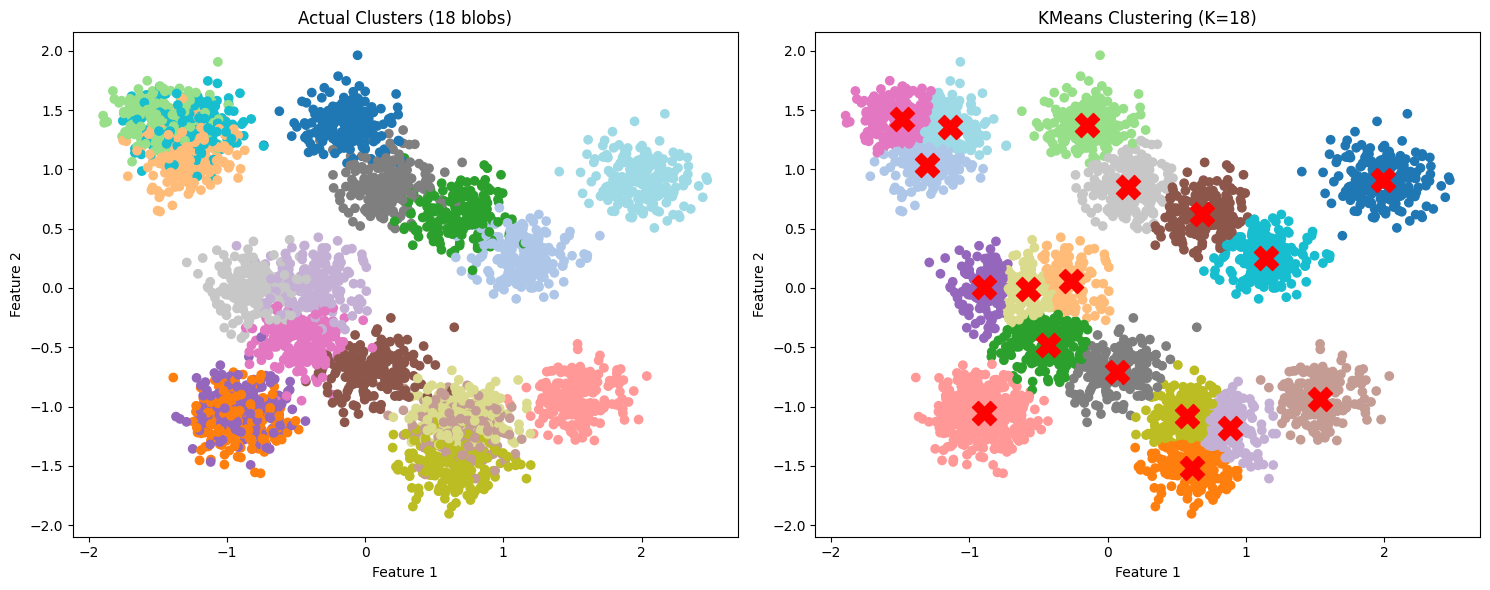

In [179]:
# Apply KMeans and Plot KMeans Results and Actual Results
# Apply KMeans
kmeans_blb = KMeans(
    n_clusters=n_blobs,
    init='k-means++',
    random_state=42,
    n_init=10
)

y_blb_kmeans = kmeans_blb.fit_predict(X_blb_sc)

plt.figure(figsize=(15,6))

# Actual Clusters
plt.subplot(1,2,1)

plt.scatter(
    X_blb_sc[:,0],
    X_blb_sc[:,1],
    c=y_blb,
    cmap='tab20'
)

plt.title(f'Actual Clusters ({n_blobs} blobs)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Predicted Clusters
plt.subplot(1,2,2)

plt.scatter(
    X_blb_sc[:,0],
    X_blb_sc[:,1],
    c=y_blb_kmeans,
    cmap='tab20'
)

plt.scatter(
    kmeans_blb.cluster_centers_[:,0],
    kmeans_blb.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X'
)

plt.title(f'KMeans Clustering (K={n_blobs})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()


In [180]:
print(y_blb_kmeans)

[ 2 13 11 ...  6  3  4]


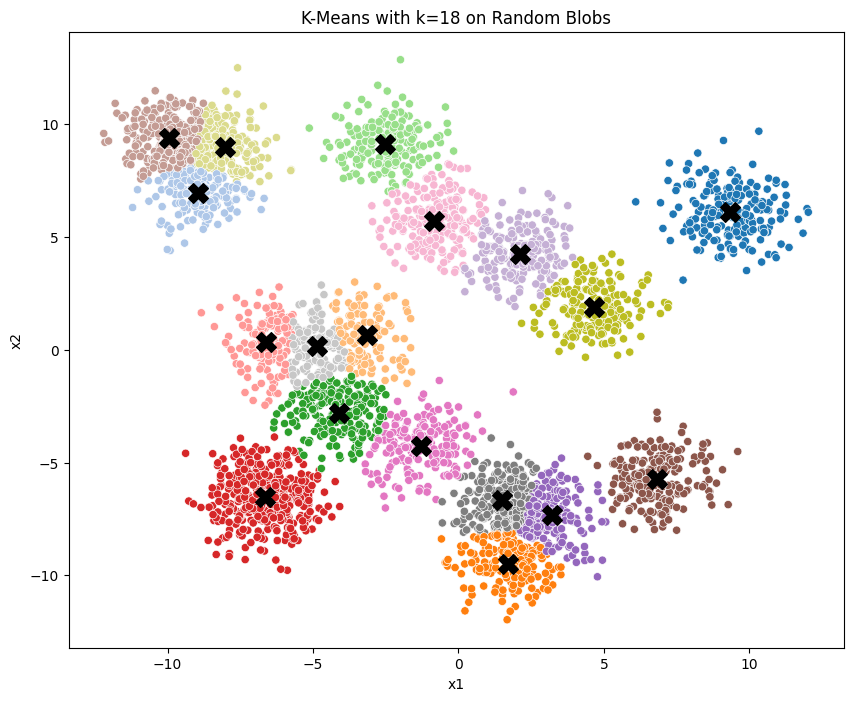

In [184]:
# Plot the clusters 
# Apply KMeans (ensures we're using fitted model matching current df_blob)
# 1. Scale first
sc_blb = StandardScaler()
X_blb_sc = sc_blb.fit_transform(df_blob[['x1', 'x2']])

kmeans_blb = KMeans(n_clusters=n_blobs, init='k-means++', random_state=42, n_init=10)
y_blb_kmeans = kmeans_blb.fit_predict(X_blb_sc)

# Plot the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_blob['x1'], y=df_blob['x2'], hue=y_blb_kmeans, palette='tab20', legend=False)

centers_orig = sc_blb.inverse_transform(kmeans_blb.cluster_centers_)
plt.scatter(centers_orig[:,0], centers_orig[:,1], s=200, c='black', marker='X')
plt.title(f'K-Means with k={n_blobs} on Random Blobs')
plt.show()
